# <center>Project 03: Linear Regression</center>

# Thông tin sinh viên

- Họ và tên: Võ Nguyễn Thảo Uyên
- MSSV: 23127542
- Lớp: 23CLC02

# Import

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold
from sklearn.utils import shuffle
# Import thêm dữ thư viện nếu cần

# Đọc dữ liệu

In [56]:
# Đọc dữ liệu  bằng pandas
train = pd.read_csv('p03.train.csv')
test = pd.read_csv('p03.test.csv')

# Lấy các đặc trưng X và giá trị mục tiêu y cho các tập huấn luyện (train) và kiểm tra (test)
X_train = train.iloc[:, :-1]    # Dataframe (chứa 5 đặc trưng huấn luyện)
y_train = train.iloc[:, -1]     # Series    (chứa 1 giá trị mục tiêu huấn luyện)

X_test = test.iloc[:, :-1]      # Dataframe (chứa 5 đặc trưng kiểm tra)
y_test = test.iloc[:, -1]       # Series    (chứa 1 giá trị mục tiêu kiểm tra)

# Sinh viên có thể sử dụng các khác nếu cần

# Cài đặt hàm

In [57]:
class OLSLinearRegression:
    def fit(self, X, y):
        '''
        This function is used to fit the model to the data. It uses the Ordinary Least Squares method to find the optimal parameters.

        Parameters
        ----------
        X : np.array
            Input data
        y : np.array
            Output data

        Returns
        -------
        self : object
            Returns the instance of the class

        '''

        X_pinv = np.linalg.inv(X.T @ X) @ X.T    # np.linalg.pinv(X)
        self.w = X_pinv @ y

        return self


    def get_params(self):
        '''
        This function is used to get the parameters of the model.

        Returns
        -------
        self.w : np.array
            Optimal parameters (column vector)
        '''
        return self.w


    def predict(self, X):
        '''
        This function is used to predict the output of the model.

        Parameters
        ----------
        X : np.array
            Input data

        Returns
        -------
        X @ self.w : np.array
            Predicted output
        '''

        return X @ self.w

def preprocess(x):
    '''
    This function is used to preprocess the data. It adds a column of ones to the input data and squares the input data.
    Note for long-term: 3 columns are 3 different features for the model to learn from.

    Parameters
    ----------
    x : np.array
        Input data

    Returns
    -------
    X : np.array
        Preprocessed input data
    '''
    X = np.hstack((np.ones((x.shape[0], 1)), x))

    return X

def mae(y, y_hat):
    '''
    This function is used to calculate the mean absolute error (MAE).

    Parameters
    ----------
    y : np.array
        Output data
    y_hat : np.array
        Predicted output data

    Returns
    -------
    np.mean(np.abs(y.ravel() - y_hat.ravel())) : float
        Mean absolute error
    '''

    return np.mean(np.abs(y.ravel() - y_hat.ravel()))   # Quick questions: What does the ravel() do?
                                                            # Why do we use it instead of np.mean(np.abs(y - y_hat))?

*Chú thích: Cần có docstrings cho các hàm.*

# Yêu cầu 1: Phân tích khám phá dữ liệu

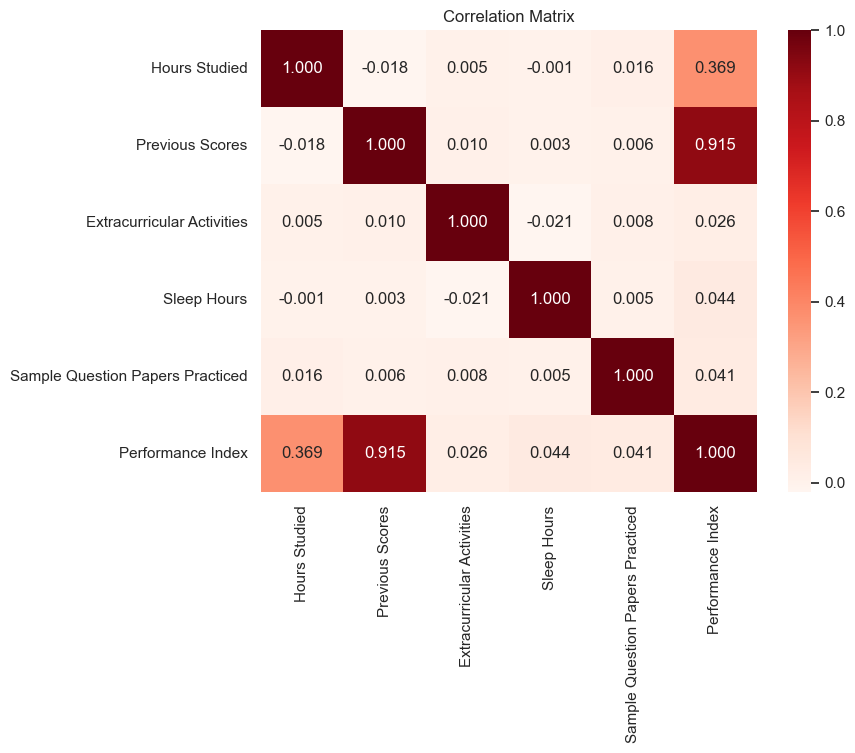

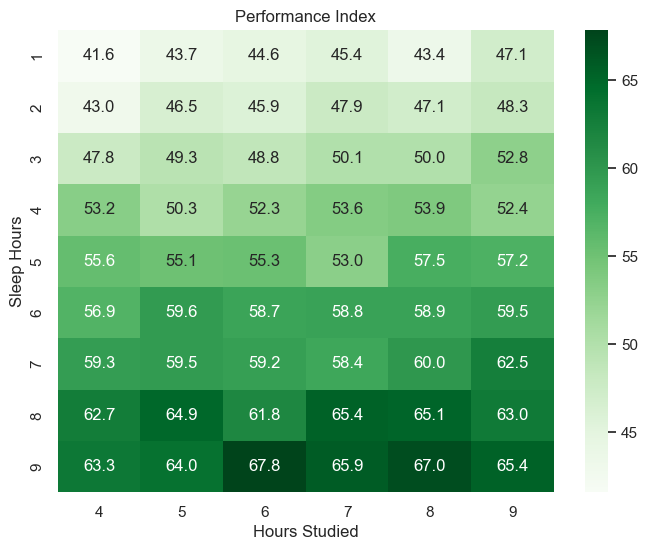

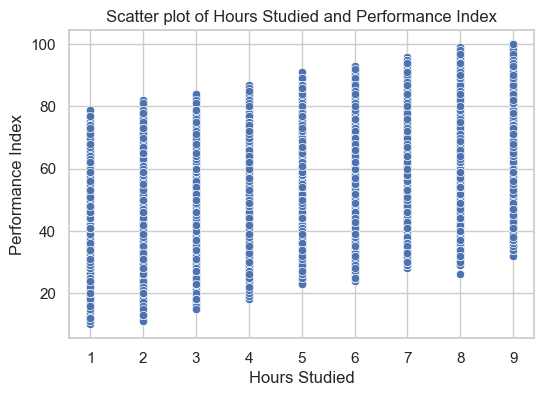

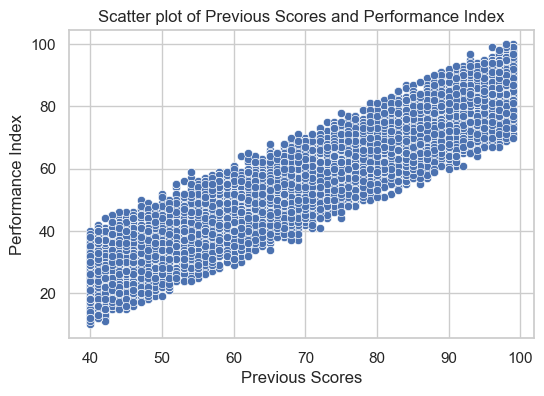

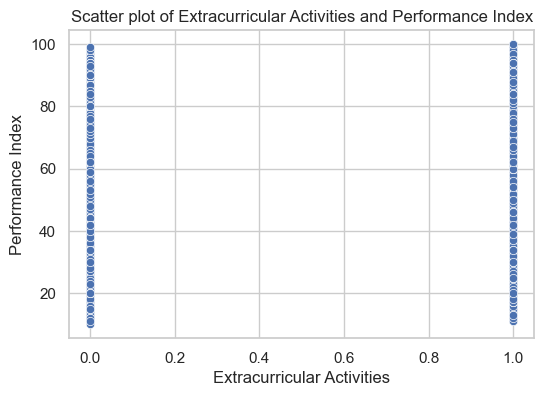

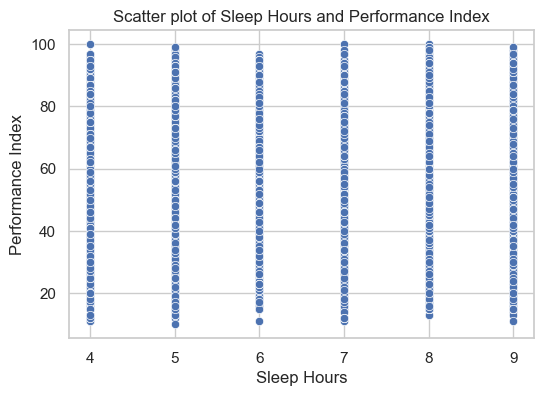

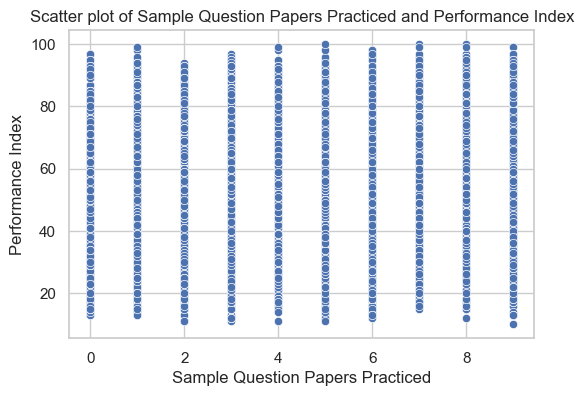

In [58]:
# Phân tích khám phá dữ liệu thông qua thống kê và các biểu đồ
# Chỉ được phân tích trên tập huấn luyện

sns.set_theme(style="whitegrid")

# Correlation heatmap
plt.figure(figsize=(8, 6))
corr = train.corr()
sns.heatmap(corr, annot=True, cmap="Reds", fmt=".3f")
plt.title("Correlation Matrix")
plt.show()

heatmap_data = train.groupby(["Hours Studied", "Sleep Hours"])["Performance Index"].mean().unstack()
plt.figure(figsize=(8, 6))
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="Greens")

plt.title("Performance Index")
plt.xlabel("Hours Studied")
plt.ylabel("Sleep Hours")
plt.show()

# Scatter plots
features = [
    "Hours Studied",
    "Previous Scores",
    "Extracurricular Activities",
    "Sleep Hours",
    "Sample Question Papers Practiced"
]

for feature in features:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(data=train, x=feature, y= "Performance Index")
    plt.title(f"Scatter plot of {feature} and Performance Index")
    plt.show()


Dựa vào Correlation heatmap ta thấy các feature "Previous Scores" và "Hours Studied" có độ tương quan cao nhất so với target là "Perfomance Index", các feature còn lại gần như không có tương quan với target -> xem xét chỉ sử dụng "Previous Scores" và "Hours Studied" để xây dựng một mô hình cho yêu cầu 2c

# Yêu cầu 2a: Xây dựng mô hình sử dụng toàn bộ 5 đặc trưng đề bài cung cấp

In [59]:
# Phần code cho yêu cầu 2a
X_train_np = preprocess(X_train.to_numpy()) # convert dataframe to np array
y_train_np = y_train.to_numpy().reshape(-1, 1)  # convert serie to np array and turn in into column vector

model_all_5 = OLSLinearRegression().fit(X_train_np, y_train_np)
model_all_5.get_params()

array([[-33.96928368],
       [  2.85202007],
       [  1.01786957],
       [  0.60428174],
       [  0.47356583],
       [  0.19237624]])

In [60]:
# Gọi hàm MAE (tự cài đặt hoặc từ thư viện) trên tập kiểm tra
X_test_np = preprocess(X_test.to_numpy())
y_test_np = y_test.to_numpy().reshape(-1, 1)

y_pred_all_5 = model_all_5.predict(X_test_np)
print("MAE:", mae(y_test_np, y_pred_all_5))

MAE: 1.595648688476289


Công thức hồi quy, phần trọng số làm tròn đến 3 chữ số thập phân, ví dụ 0.012345 $\to$ 0.012

$$\text{Student Performance} = -33.969 +  2.852 \times \text{Hours Studied} + 1.018 \times \text{Previous Scores} + 0.604 \times \text{Extracurricular Activities} + 0.474 \times \text{Sleep Hour} + 0.192 \times \text{Sample Question Papers Practiced}$$

# Yêu cầu 2b: Xây dựng mô hình sử dụng duy nhất 1 đặc trưng, tìm mô hình cho kết quả tốt nhất

Lưu ý: Khi sử dụng cross-validation, sinh viên cần xáo trộn dữ liệu 1 lần duy nhất và thực hiện trên toàn bộ đặc trưng

In [61]:
# Phần code cho yêu cầu 2b
# Tìm ra đặc trưng tốt nhất (trong 5 đặc trưng)
# In ra các kết quả cross-validation như yêu cầu

def cross_validate_one_feature(X, y, feature_name, k=5):
    '''
    Thực hiện cross-validation với 1 đặc trưng
    Input:
      X: DataFrame chứa các đặc trưng
      y: Series hoặc mảng numpy chứa nhãn
      k: số lượng folds (mặc định 5)

    Output:
      mae_mean: MAE trung bình của k lần

    '''
    maes = []
    kf = KFold(n_splits=k, shuffle=False)  # Không shuffle bên trong

    X_feature = X[[feature_name]].to_numpy()
    y = y.to_numpy().reshape(-1, 1)

    for train_index, val_index in kf.split(X_feature):
        X_train, X_val = X_feature[train_index], X_feature[val_index]
        y_train, y_val = y[train_index], y[val_index]

        X_train_proc = preprocess(X_train)
        X_val_proc = preprocess(X_val)

        model = OLSLinearRegression()
        model.fit(X_train_proc, y_train)
        y_pred = model.predict(X_val_proc)

        maes.append(mae(y_val, y_pred))

    return np.mean(maes)


# Shuffle 1 lần duy nhất ở đây
X_shuffled_1_feature, y_shuffled_1_feature= shuffle(X_train, y_train, random_state=42)

# Chạy cho tất cả feature
features = [
    "Hours Studied",
    "Previous Scores",
    "Extracurricular Activities",
    "Sleep Hours",
    "Sample Question Papers Practiced"
]

results = []
for i, feature in enumerate(features, 1):
    mae_score = cross_validate_one_feature(X_shuffled_1_feature, y_shuffled_1_feature, feature, k=5)
    results.append((i, feature, round(mae_score, 3)))

df_results = pd.DataFrame(results, columns=["STT", "Mô hình", "MAE"])
print(df_results)



   STT                           Mô hình     MAE
0    1                     Hours Studied  15.449
1    2                   Previous Scores   6.618
2    3        Extracurricular Activities  16.196
3    4                       Sleep Hours  16.187
4    5  Sample Question Papers Practiced  16.188


In [62]:
# Huấn luyện lại mô hình best_feature_model với đặc trưng tốt nhất trên toàn bộ tập huấn luyện
best_feature_model = OLSLinearRegression()
best_feature_model.fit(preprocess(X_train[["Previous Scores"]].to_numpy()), y_train.to_numpy().reshape(-1, 1))

best_feature_model.get_params()

array([[-14.98864578],
       [  1.01050301]])

In [63]:
# Gọi hàm MAE (tự cài đặt hoặc từ thư viện) trên tập kiểm tra với mô hình best_feature_model
y_pred = best_feature_model.predict(preprocess(X_test[["Previous Scores"]].to_numpy()))
mae_val = mae(y_test.to_numpy().reshape(-1, 1), y_pred)
print("MAE:",mae_val)

MAE: 6.5442772934525015


Công thức hồi quy (dựa trên mô hình đặc trưng tốt nhất), phần trọng số làm tròn đến 3 chữ số thập phân, ví dụ 0.012345 $\to$ 0.012

$$\text{Student Performance} = -14.989 + 1.011 \times \text{Previous Scores}$$

# Yêu cầu 2c: Sinh viên tự xây dựng/thiết kế mô hình, tìm mô hình cho kết quả tốt nhất

## Xây dựng/Thiết kế mô hình

In [64]:
# Trình bày toàn bộ code liên quan đến việc thiết kế mô hình
def preprocess_custom(df):
    '''
    Hàm preprocess cho mô hình 2
    Kết hợp Hours Studied + Sleep Hours thành 1 feature
    '''
    # Lấy các feature gốc
    X1 = (df["Previous Scores"]).to_numpy().reshape(-1, 1)
    X2 = df["Extracurricular Activities"].to_numpy().reshape(-1, 1)
    X3 = df["Sample Question Papers Practiced"].to_numpy().reshape(-1, 1)

    study_sleep_hours = (df["Sleep Hours"] + df["Hours Studied"]).to_numpy().reshape(-1, 1)

    # Ghép lại và thêm bias
    X = np.hstack((np.ones((len(df), 1)), X1, X2, X3, study_sleep_hours))
    return X



def preprocess_GAM(df):
    '''
    Hàm preprocess với các feature gốc + GAM feature
    '''
    # Lấy các feature gốc
    X1 = df["Hours Studied"].to_numpy().reshape(-1, 1)
    X2 = df["Previous Scores"].to_numpy().reshape(-1, 1)
    X3 = df["Extracurricular Activities"].to_numpy().reshape(-1, 1)
    X4 = df["Sleep Hours"].to_numpy().reshape(-1, 1)
    X5 = df["Sample Question Papers Practiced"].to_numpy().reshape(-1, 1)



    # GAM feature cho Sleep Hours
    sh_below = np.minimum(X4 - 8, 0)

    # Ghép tất cả lại và thêm bias
    X = np.hstack((
        np.ones((len(df), 1)),  # bias
        X1, X2, X3, X4, X5,
        sh_below
    ))
    return X



## Tìm mô hình cho kết quả tốt nhất

Lưu ý: Khi sử dụng cross-validation, sinh viên cần xáo trộn dữ liệu 1 lần duy nhất và thực hiện trên toàn bộ $m$ mô hình mà sinh viên thiết kế

In [65]:
# Phần code cho yêu cầu 2c
# Tìm ra mô hình tốt nhất (trong m mô hình mà sinh viên tự thiết kế)
# In ra các kết quả cross-validation như yêu cầu

def cross_validate_custom(X, y, k=5):
    '''
    Thực hiện k-fold cross-validation cho mô hình custom:

    Input:
      X: DataFrame chứa các đặc trưng
      y: Series hoặc mảng numpy chứa nhãn
      k: số lượng folds (mặc định 5)

    Output:
      mae_mean: MAE trung bình của k lần
    '''
    kf = KFold(n_splits=k, shuffle=False)
    maes = []

    y = y.to_numpy().reshape(-1, 1)

    for train_index, val_index in kf.split(X):
        # Chia tập train/val theo index
        X_train_df, X_val_df = X.iloc[train_index], X.iloc[val_index]
        y_train, y_val = y[train_index], y[val_index]

        # Preprocess
        X_train_proc = preprocess_custom(X_train_df)
        X_val_proc = preprocess_custom(X_val_df)

        # Train model
        model = OLSLinearRegression()
        model.fit(X_train_proc, y_train)

        # Predict
        y_pred = model.predict(X_val_proc)

        # Calculate MAE
        mae_value = mae(y_val, y_pred)
        maes.append(mae_value)

    return np.mean(maes)

def cross_validate_two_features(X, y, k=5):
    '''
    Mô hình 1
    Thực hiện k-fold cross-validation với 2 đặc trưng:
    "Hours Studied" và "Previous Scores"

    Input:
      X: DataFrame chứa các đặc trưng
      y: Series chứa nhãn
      k: số lượng folds (mặc định 5)

    Output:
      mae_mean: MAE trung bình của k lần
    '''
    kf = KFold(n_splits=k, shuffle=False)
    maes = []

    X_features = X[["Hours Studied", "Previous Scores"]].to_numpy()
    y = y.to_numpy().reshape(-1, 1)

    for train_index, val_index in kf.split(X_features):
        X_train, X_val = X_features[train_index], X_features[val_index]
        y_train, y_val = y[train_index], y[val_index]

        # Preprocess
        X_train_proc = preprocess(X_train)
        X_val_proc = preprocess(X_val)

        # Train model
        model = OLSLinearRegression()
        model.fit(X_train_proc, y_train)

        # Predict
        y_pred = model.predict(X_val_proc)

        # Tính MAE
        mae_value = mae(y_val, y_pred)
        maes.append(mae_value)

    return np.mean(maes)


def cross_validate_GAM(X, y, k=5):
    '''
    Thực hiện k-fold cross-validation cho mô hình GAM:

    Input:
      X: DataFrame chứa các đặc trưng
      y: Series hoặc mảng numpy chứa nhãn
      k: số lượng folds (mặc định 5)

    Output:
      mae_mean: MAE trung bình của k lần
    '''
    kf = KFold(n_splits=k, shuffle=False)
    maes = []

    y = y.to_numpy().reshape(-1, 1)

    for train_index, val_index in kf.split(X):
        # Chia tập train/val theo index
        X_train_df, X_val_df = X.iloc[train_index], X.iloc[val_index]
        y_train, y_val = y[train_index], y[val_index]

        # Preprocess
        X_train_proc = preprocess_GAM(X_train_df)
        X_val_proc = preprocess_GAM(X_val_df)

        # Train model
        model = OLSLinearRegression()
        model.fit(X_train_proc, y_train)

        # Predict
        y_pred = model.predict(X_val_proc)

        # Calculate MAE
        mae_value = mae(y_val, y_pred)
        maes.append(mae_value)

    return np.mean(maes)


X_shuffled, y_shuffled = shuffle(X_train, y_train, random_state=42) # shuffle dataframe

mae_avg = cross_validate_two_features(X_shuffled, y_shuffled, k=5)
print(f"MAE trung bình (2 feature): {mae_avg:.3f}")


mae_avg_2 = cross_validate_custom(X_shuffled, y_shuffled, k=5)
print(f"MAE trung bình (model sử dụng feature tạo ra từ 2 feature): {mae_avg_2:.3f}")

mae_avg_3 = cross_validate_GAM(X_shuffled, y_shuffled, k=5)
print(f"MAE trung bình (GAM model): {mae_avg_3:.3f}")


MAE trung bình (2 feature): 1.816
MAE trung bình (model sử dụng feature tạo ra từ 2 feature): 3.240
MAE trung bình (GAM model): 1.622


In [66]:
# Huấn luyện lại mô hình my_best_model trên toàn bộ tập huấn luyện
X_tra = preprocess_GAM(X_train) # convert dataframe to np array
y_tra = y_train.to_numpy().reshape(-1, 1)  # convert serie to np array and turn in into column vector

my_best_model = OLSLinearRegression().fit(X_tra, y_tra)
my_best_model.get_params()

array([[-34.64766687],
       [  2.85197284],
       [  1.01786952],
       [  0.60454398],
       [  0.55413544],
       [  0.19230434],
       [ -0.09359332]])

In [67]:
# Gọi hàm MAE (tự cài đặt hoặc từ thư viện) trên tập kiểm tra với mô hình my_best_model
X_te = preprocess_GAM(X_test)
y_te = y_test.to_numpy().reshape(-1, 1)

y_pred_best = my_best_model.predict(X_te)
print("MAE:", mae(y_te, y_pred_best))

MAE: 1.5952151066265063


Công thức hồi quy (dựa trên mô hình tốt nhất mà sinh viên tự xây dựng/thiết kế), phần trọng số làm tròn đến 3 chữ số thập phân, ví dụ 0.012345 $\to$ 0.012

$$\text{Student Performance} = -34.648 + 2.852 \times \text{Hours Studied} + 1.018 \times \text{Previous Score} + 0.605 \times \text{Extracurricular Activities} + 0.554 \times \text{Sleep Hours} + 0.192 \times \text{Sample Question Papers Practiced} - 0.094 \text{ min{Sleep Hours - 8, 0}}$$